Comparing 1st and 2nd Semester

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df_raw = pd.read_csv("../student_data_categorized.csv")

In [9]:
selected_cols = [col for col in df_raw.columns if '_' in col or col == "Target"]

df_units = df_raw[selected_cols]

df_units.head()

,1st_sem_credited,1st_sem_enrolled,1st_sem_evaluations,1st_sem_approved,1st_sem_grade,1st_sem_without_eval,2nd_sem_credited,2nd_sem_enrolled,2nd_sem_evaluations,2nd_sem_approved,2nd_sem_grade,2nd_sem_without_eval,Target
0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,Dropout
1,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,Graduate
2,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,Dropout
3,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,Graduate
4,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,Graduate


In [28]:
# difference in performance

df_units = df_units[(df_units['1st_sem_grade'] != 0) | (df_units['2nd_sem_grade'] != 0)]

df_units["grade_diff"] = df_units["2nd_sem_grade"] - df_units["1st_sem_grade"]
df_units["grade_diff"] = df_units["2nd_sem_approved"] - df_units["1st_sem_approved"]

df_units["%_credits_completed_1st_sem"] = np.where(
    df_units["1st_sem_enrolled"] != 0,
    df_units["1st_sem_credited"] / df_units["1st_sem_enrolled"],
    0
)

df_units["%_credits_completed_2nd_sem"] = np.where(
    df_units["2nd_sem_enrolled"] != 0,
    df_units["2nd_sem_credited"] / df_units["2nd_sem_enrolled"],
    0
)

df_units["%_credits_completed_diff"] = df_units["%_credits_completed_2nd_sem"] - df_units["%_credits_completed_1st_sem"]
df_units



,1st_sem_credited,1st_sem_enrolled,1st_sem_evaluations,1st_sem_approved,1st_sem_grade,1st_sem_without_eval,2nd_sem_credited,2nd_sem_enrolled,2nd_sem_evaluations,2nd_sem_approved,2nd_sem_grade,2nd_sem_without_eval,Target,grade_diff,%_credits_completed_1st_sem,%_credits_completed_2nd_sem,%_credits_completed_diff,grade_trend
1,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,Graduate,0,0.0,0.0,0.0,Stable
3,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,Graduate,-1,0.0,0.0,0.0,Declined
4,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,Graduate,1,0.0,0.0,0.0,Improved
5,0,5,10,5,11.857143,0,0,5,17,5,11.500000,5,Graduate,0,0.0,0.0,0.0,Stable
6,0,7,9,7,13.300000,0,0,8,8,8,14.345000,0,Graduate,1,0.0,0.0,0.0,Improved
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,0,6,7,5,13.600000,0,0,6,8,5,12.666667,0,Graduate,0,0.0,0.0,0.0,Stable
4420,0,6,6,6,12.000000,0,0,6,6,2,11.000000,0,Dropout,-4,0.0,0.0,0.0,Declined
4421,0,7,8,7,14.912500,0,0,8,9,1,13.500000,0,Dropout,-6,0.0,0.0,0.0,Declined
4422,0,5,5,5,13.800000,0,0,5,6,5,12.000000,0,Graduate,0,0.0,0.0,0.0,Stable


In [29]:
def categorize_performance(diff, threshold=0.5):
    if diff > threshold:
        return 'Improved'
    elif diff < -threshold:
        return 'Declined'
    else:
        return 'Stable'

In [30]:
df_units['grade_trend'] = df_units['grade_diff'].apply(categorize_performance)

print("Stable count:", len(df_units[(df_units["grade_trend"] == "Stable")]))
print("Improved count:", len(df_units[(df_units["grade_trend"] == "Improved")]))
print("Declined count:", len(df_units[(df_units["grade_trend"] == "Declined")]))

df_units.head()


Stable count: 1743
Improved count: 825
Declined count: 1180


,1st_sem_credited,1st_sem_enrolled,1st_sem_evaluations,1st_sem_approved,1st_sem_grade,1st_sem_without_eval,2nd_sem_credited,2nd_sem_enrolled,2nd_sem_evaluations,2nd_sem_approved,2nd_sem_grade,2nd_sem_without_eval,Target,grade_diff,%_credits_completed_1st_sem,%_credits_completed_2nd_sem,%_credits_completed_diff,grade_trend
1,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,Graduate,0,0.0,0.0,0.0,Stable
3,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,Graduate,-1,0.0,0.0,0.0,Declined
4,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,Graduate,1,0.0,0.0,0.0,Improved
5,0,5,10,5,11.857143,0,0,5,17,5,11.500000,5,Graduate,0,0.0,0.0,0.0,Stable
6,0,7,9,7,13.300000,0,0,8,8,8,14.345000,0,Graduate,1,0.0,0.0,0.0,Improved


In [31]:
# compare trend to target
ct = pd.crosstab(df_units['grade_trend'], df_units['Target'])
print(ct)

Target       Dropout  Enrolled  Graduate
grade_trend                             
Declined         515       287       378
Improved         150       210       465
Stable           210       242      1291


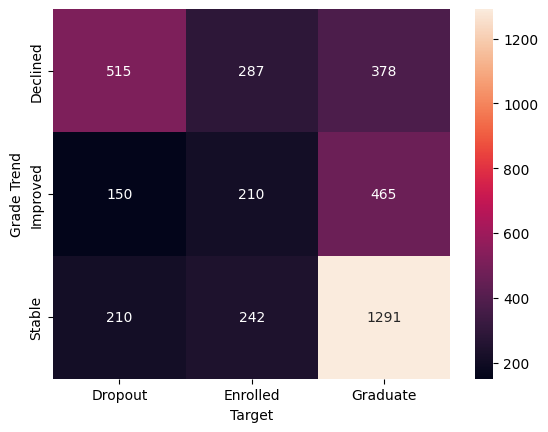

In [ ]:
sns.heatmap(ct, annot=True, fmt='d')
plt.xlabel('Target')
plt.ylabel('Grade Trend between 1st and 2nd semester')
plt.show()

We'd expect an improved grade trend to correlate with graduate, but that doesn't seem like the case here. Although it does make sense that the proportion of students who had an improved grade trend had the lowest dropout count, it's a bit weird that a stable Grade tend correlated to a Dropout target more than an Enrolled target.

In addition, we'd expect the % of declined students to have a much higher dropout rate than graduate rate, but instead, the numbers are a lot closer than we would've expected.

Update: after filtering rows where grade = 0, the trend becomes slightly clearer. A stable grade trend correlates significantly more to a Graduate target, and less to a dropout/enrolled. 

### Comparing with units approved